# Final Project

Import Statements

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import seaborn as sns

Load dataset

In [2]:
# Load dataset
df = pd.read_csv('amazon.csv')

File Cleaning

In [3]:
# get rid of anything but the numbers and decimal points
# and convert to numeric for price categories
def clean_price(x):
    if pd.isna(x):
        return None
    x = re.sub(r'[^\d.]', '', x)
    return pd.to_numeric(x, errors='coerce')

df['discounted_price'] = df['discounted_price'].apply(clean_price)
df['actual_price'] = df['actual_price'].apply(clean_price)

# get rid of percent sign and convert to numeric float for discount percentages
df['discount_percentage'] = (df['discount_percentage'].str.replace('%','', regex=False).astype(float))

# convert strings to numeric and get rid of any commas
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df['rating_count'] = (df['rating_count'].str.replace(',', '', regex=False))

df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

# split category into an actual list
df['category_list'] = df['category'].str.split('|')
# drop category column
df.drop('category', axis=1, inplace=True)

# df has now been cleaned and stored in cleaned df
cleaneddf = df
print("Cleaning complete")


Cleaning complete


In [4]:
cleaneddf.head()

,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,category_list
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,"[Computers&Accessories, Accessories&Peripheral..."
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,"[Computers&Accessories, Accessories&Peripheral..."
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,"[Computers&Accessories, Accessories&Peripheral..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,"[Computers&Accessories, Accessories&Peripheral..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,154.0,399.0,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,"[Computers&Accessories, Accessories&Peripheral..."


## Question 1) Statistical Question
#### What are the top ten categories with the highest average discount percentage?

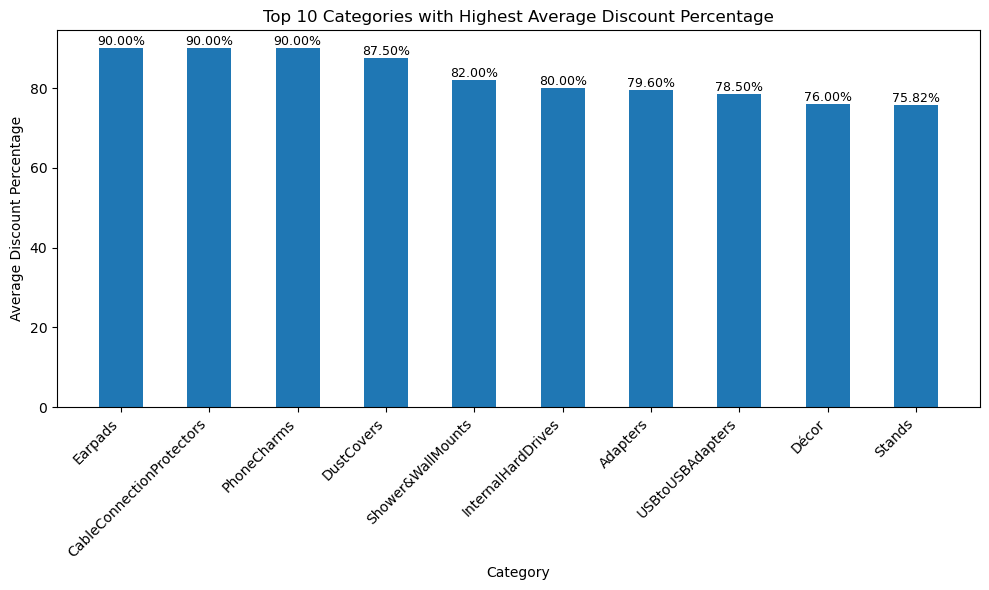

In [10]:
# reload the df
df = cleaneddf

# give each category their own row to more easily work on them
df_exploded = df.explode('category_list')

# Group by category and compute the average discount percentage
category_discount = (df_exploded.groupby('category_list')['discount_percentage'].mean())

# sort the values descending and grab the top ten
category_discount_head = category_discount.sort_values(ascending=False).head(10)

# Plot bar graph
plt.figure(figsize=(10, 6))
bars = plt.bar(category_discount_head.index, category_discount_head.values, width=.5)
# add the values above the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}%", ha='center', va='bottom', fontsize=9)
plt.title("Top 10 Categories with Highest Average Discount Percentage")
plt.xlabel("Category")
plt.ylabel("Average Discount Percentage")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('StatisticalQuestion.png')
plt.show()


These results show us that Earpads, CableConnectionProtectors, and PhoneCharms are the three products that have the highest average discount, with a value of 90%, across all bought products. The rest of the data show the top ten products that are most discounted across every product in the dataset.

## Question 2) Decision Tree
#### Can we predict whether a products' rating will be high or low based on price, discount, and rating count?

Accuracy: 0.7679180887372014

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.12      0.21        74
           1       0.77      0.99      0.86       219

    accuracy                           0.77       293
   macro avg       0.76      0.55      0.54       293
weighted avg       0.76      0.77      0.70       293



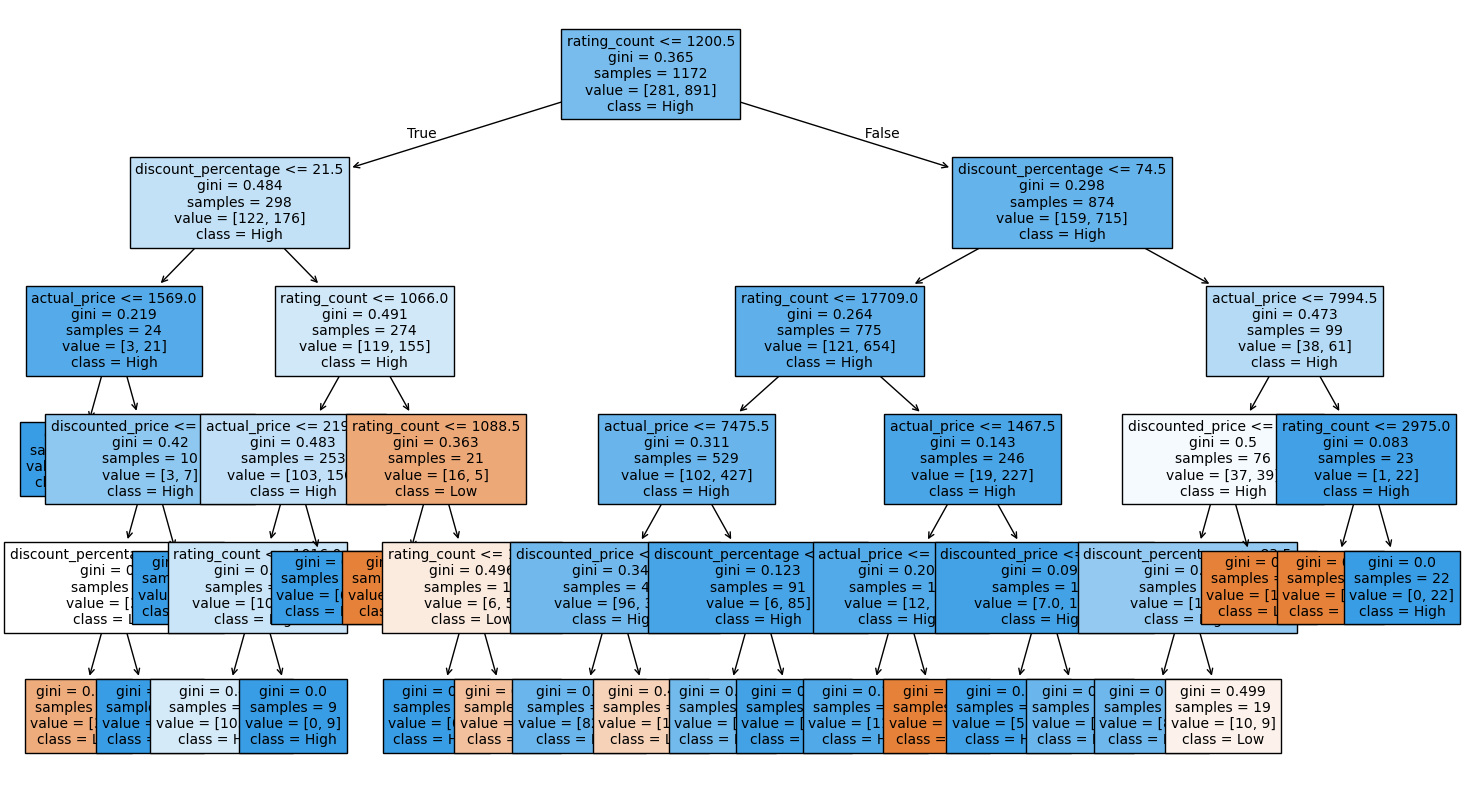

In [11]:
# reload the df
df = cleaneddf

# set the target variable
df['high_rating'] = (df['rating'] >= 4.0).astype(int)

# select attributes for use
features = [
    'discounted_price',
    'actual_price',
    'discount_percentage',
    'rating_count'
]

X = df[features]
y = df['high_rating']

# split the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train the decision tree
clf = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
clf.fit(X_train, y_train)

# evaluate the model
y_pred = clf.predict(X_test)

# print the results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# plot the final tree for human readabiltiy
plt.figure(figsize=(18, 10))
plot_tree(
    clf,
    filled=True,
    feature_names=features,
    class_names=['Low', 'High'],
    fontsize=10
)
plt.savefig('DecisionTree')
plt.show()


1) Accuracy: moderate accuracy because it is between 70 and 80
2) Precision: moderate again
3) Recall: weak to moderate
4) F1 Score Accuracy: moderate
5) Support: There are much more high rated products than los rated ones which will skew the results

rating_count: It is the frist metric so it is what drives the rating the most
discount_percentage: It is the second metric so it is the second most important for deciding the rating
actual_price: this shares the same level as rating_count again but it is the third most important 
discounted_price: this is the last metric to show up meaning it has the least importance out of the four attributes I chose

These results show a higher discount percentage and a higher rating count matter the most when it comes to the rating value.

1) decision
2) gini = measure of impurity (0.5 is perfect split, 0 is completley onesided
3) samples = number of samples it used
4) value = [low, high]
5) class = result

## Question 3) Naive Bayes
#### Can we classify products into high_sales vs. low_sales (rating_count) based on price, discount, and rating values?

Accuracy: 0.5694822888283378

Confusion Matrix:
 [[146  40]
 [118  63]]

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.78      0.65       186
           1       0.61      0.35      0.44       181

    accuracy                           0.57       367
   macro avg       0.58      0.57      0.55       367
weighted avg       0.58      0.57      0.55       367



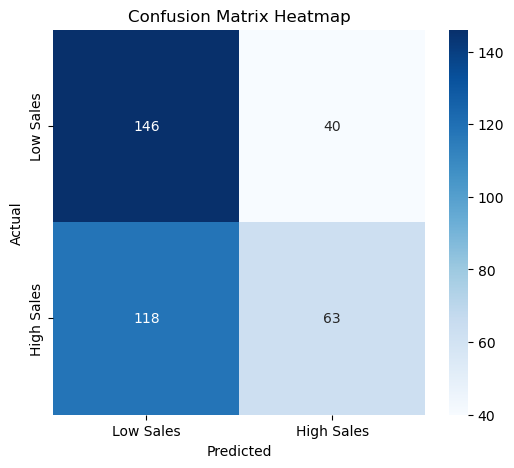

In [13]:
df = cleaneddf

# set the target variable as ratincount > median of rating count
median_sales = df['rating_count'].median()
df['high_sales'] = (df['rating_count'] > median_sales).astype(int)

# select attributesfor use 
features = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', ]
X = df[features]
y = df['high_sales']

# switch out the NaN values for the median using impute
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.25, random_state=42
)

# scale the numeric attributes to fit together
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train the Naive Bayes model
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# make the predictions
y_pred = nb.predict(X_test_scaled)

# check the accuracy of the predictions
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# print the results
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

# create a heatmap for the results
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Sales", "High Sales"],
            yticklabels=["Low Sales", "High Sales"])

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('NaiveBayes')
plt.show()

This has a very low accuracy of only ~57% which means that the price, discount, and rating values are not very good indicators of whether or not the rating count would be high or low. This makes sense because usually the rating count shows popularity. And popular items aren't necessarily cheap or expensive they are popular for different reasons. And the rating value also makes sense for not mattering too much because an item can have a high rating count but with a lot of bad ratings just because this popular item ended up being worse than people expected. So, in conclusion the rating count somewhat depends on the price, discount, and rating value but also has many more factors that determine its count.

Because there is such a high value in the bottom left corner that means that the model predicted a lot of products that had high rating counts to be low. 

Looking at the ratio from left to right we can see that the model was a lot better at predicting the low sales than high sales. The low sales true vs negative ratio is 40/146 or ~27% wrong. For high sales however that ratio is 63/118 or ~53% wrong. This shows us that the moidel was much better at predicting a low rating count than a high one. 